# Semantic Spotter Project: Build a RAG System using Lammaindex  


### Problem Statement

Build a project in the insurance domain. The goal of the project will be to build a robust generative search system capable of effectively and accurately answering questions from various policy documents. Using LlamaIndex to build the generative search application.



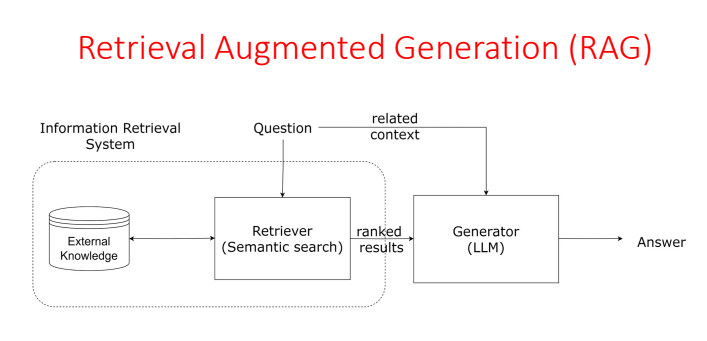

### RAG
**Retrieval-Augmented Generation** (RAG) is a method that improves the responses of a language model by using information from a knowledge base. It's like giving the model a library of information to reference when it's generating a response. This makes the model's responses more accurate and relevant.

RAG combines two types of models:
- ***retrieval models***, which pull data from a knowledge base, and
- ***generative models*** , which create the responses.

This combination makes RAG more powerful than a model that only generates responses. It can answer difficult questions and provide more informative responses.

## LlamaIndex
**LlamaIndex** is a framework for building context-augmented LLM applications. Context augmentation refers to any use case that applies LLMs on top of your private or domain-specific data.

Some popular use cases include the following:
* Question-Answering Chatbots (commonly referred to as RAG, or "Retrieval-Augmented Generation")
* Document Understanding and Extraction
* Autonomous Agents that can perform research and take actions

LlamaIndex provides the tools to build any of these above use cases from prototype to production. The tools allow you to ingest and process this data and implement complex queries. It combines data access with LLM prompting.

To install the library:

`pip install llama-index`

LlamaIndex is an innovative data framework specially designed to support LLM-based RAG framework application development. It offers an advanced framework that empowers developers to integrate diverse data sources with large language models.

LlamaIndex includes a variety of file formats, such as PDFs and PowerPoints, as well as applications like Notion and Slack and even databases like Postgres and MongoDB.

The framework brings an array of connectors that assist in data ingestion, facilitating a seamless interaction with LLMs. Moreover, LlamaIndex boasts an efficient data retrieval and query interface.

LlamaIndex enables developers to input any LLM prompt and, in return, receive an output that is both context-rich and knowledge-augmementation.
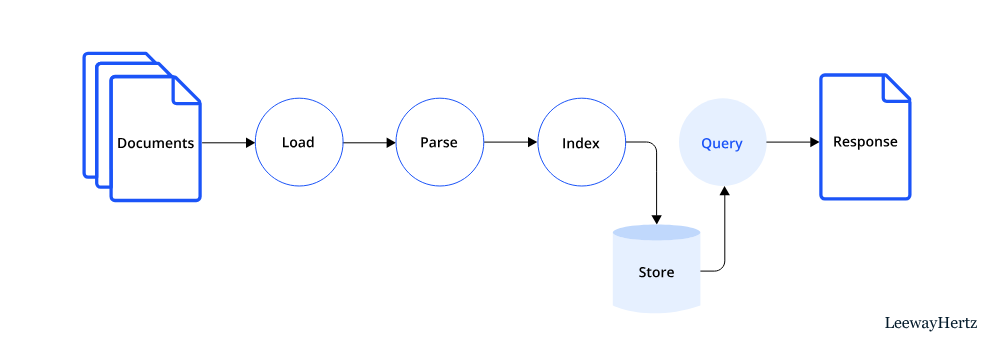





#### Why using Lamaindex
key Feature of LlamaIndex:
*  Focus on search and retrieval: LlamaIndex is specifically tailored for building search and retrieval applications. Its       primary purpose is to ease the process of querying LLMs and retrieving relevant documents or data based on user queries.

*   Simplicity and efficiency: LlamaIndex is designed to be efficient, especially in handling large data volumes. It offers a      straightforward interface for interacting with LLMs, simplifying the process of searching and retrieving data.

*   Data connectors allow ingestion from various data sources and formats.

*   It can synthesize data from multiple documents or heterogeneous data sources.
* It provides numerous integrations with vector stores, ChatGPT plugins, tracing tools, LangChain, and more.

###  Overall Product Specifications

***Problem Statement*** - Build a robust generative search system capable of effectively and accurately answering questions from a list of HDFC Insurance policy documents.

***Solution Strategy*** - Build a solution which should solve the following requirements:

- Users would get responses from insurance policy knowledge base.
- If user want to perform a query system must be able to response to query accurately.
- If they want to refer to the original page from which the bot is responding, the bot should provide a citation as well.

***Goal*** - Solving the above requirements well in and would ensure that the accuracy of the overall model is good.

***Data Used*** -HDFC Insuracne policy documets sotred in single folder

***Tools used*** - LlamaIndex has been used due to its powerful query engine, fast data processing using data loaders and directory readers as well as easier and faster implementation using fewer lines of code,LLM-gpt-3.5-turbo, diskcache for storing cache, SentenceTransformerRerank- model="cross-encoder/ms-marco-MiniLM-L-2-v2 for Rerank and gpt-4 for evaluation.

### Proposed Solution

In this section, we go ahead and actually build the solution that we proposed in the previous step using Llamindex. Here is the architecture.

#####  Discriptions about the Architecture:


1. Documents: List of  seven HDFC insurance documents provides inside a single folder.

2. Open API embedding: OpenAPI embedding as Vector DB for indexing insurance documents in the form of embedding.

3. Query Engine: We are using Query Engine Module of Llammaindex for performing semantic Search. Query Engine will use internally Retriever and SentenceTransformerRerank- model="cross-encoder/ms-marco-MiniLM-L-2-v2 retrieve top-k relevant nodes from embedding.

4. LLM: top k-documents  along with user query will be passed to LLM to generate the accurate response.

5. Caching:" Caching is being used to improve the read operation. Recent similar search will be store in Caching and user query first will be served from Cache. If user query not found in cache, then query will be forwarded to query engine and then LLM to generate the response. 

6. Meta data : Along with Response we are also returning docs reference and similarly score to improve the user confidence towards the implemented RAG system.

7. SentenceTransformerRerank- model="cross-encoder/ms-marco-MiniLM-L-2-v2  Is being used to rerank the query based on semantic score.

8. Evaluation- LLM-gpt4 is used for evaluation on matrices relevancy ,faithfulness and correctness.



#### Importing and installing Necessary libraries 

In [1]:
!pip install -U -qq llama-index

In [2]:
!pip install -qq pypdf
!pip install -qq openai

In [3]:

!pip install -qq llama-index-llms-openai
!pip install -qq llama-index

In [4]:
import warnings
warnings.filterwarnings('ignore')


In [5]:
# NOTE: This is ONLY necessary in jupyter notebook.
# Details: Jupyter runs an event-loop behind the scenes.
#          This results in nested event-loops when we start an event-loop to make async queries.
#          This is normally not allowed, we use nest_asyncio to allow it for convenience.
import nest_asyncio
nest_asyncio.apply()

In [6]:
# Llama index already has its bundle which comes with OpenAI package included and will work even if you do not import openai separately.
from llama_index.llms.openai import OpenAI
from llama_index.core.llms import ChatMessage
import os
import openai

In [67]:
from llama_index.core.evaluation import (
    CorrectnessEvaluator,
    FaithfulnessEvaluator,
    RelevancyEvaluator,
)
import re

### Set OpenAPI key

In [7]:
folder_path=r'D:\GenAI\Keys\\'
with open(folder_path + "OpenAI_API_Key.txt", "r") as f:
    openai.api_key = ' '.join(f.readlines())


 ### Data Loading (Ingestion)

Before your LLM can act on your data, you need to process and load it. The way LlamaIndex does this is via data connectors, also called `Reader`. Data connectors ingest data from different data sources and format the data into `Document` objects. A `Document` is a collection of data (currently text, and in future, images and audio) and metadata about that data.


***3 ways to do this***

- If you have a single file containing all the required data, use a data loader or reader from [LLamahub](https://llamahub.ai/)
    https://llamahub.ai/l/readers/llama-index-readers-file

- If you have multiple files, the simplest way is to use *SimpleDirectoryReader*. It is built in to LlamaIndex and can read a variety of formats including Markdown, PDFs, Word documents, PowerPoint decks, images, audio and video. Just ensure that for reading each file type the necessary dependency libraries are already installed.
    https://docs.llamaindex.ai/en/stable/module_guides/loading/simpledirectoryreader.html
    
    - Llamaparse: A very recent method for parsing documents. This is claimed as the first **GenAI native document parsing platform** .

    - [LinkedIN Post](https://www.linkedin.com/posts/llamaindex_were-excited-to-officially-launch-llamaparse-activity-7173714437860782080-Zqmf)

    - [Blog Post](https://www.llamaindex.ai/blog/launching-the-first-genai-native-document-parsing-platform)

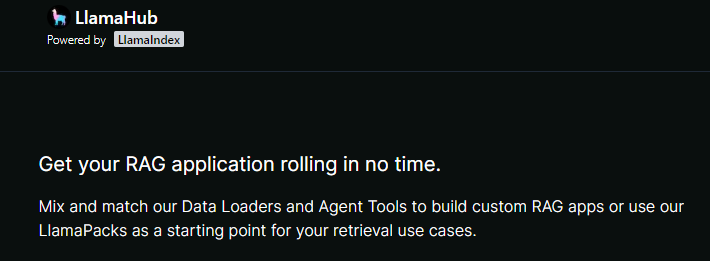

##### Using SimpleDirectoryReader
Here are some attributes that can be passed to the `SimpleDirectoryReader`:

* `input_dir`: The directory from which you have to load files.
* `recursive`: If set to *True*, it will read files from subdirectories too.
* `input_files`: A list of specific file paths to load.
* `exclude`: A list of file paths to exclude.

Refer to [this documentation](https://docs.llamaindex.ai/en/stable/module_guides/loading/simpledirectoryreader/) for more info on SimpleDirectoryReader

In [9]:
# reading the multiple files for insurance data.
from llama_index.core import SimpleDirectoryReader,VectorStoreIndex
from IPython.display import display, HTML

In [10]:
reader = SimpleDirectoryReader(input_dir=r"D:\GenAI\semantic spotter projects\data")

In [11]:
# Use the load_data() method to read the files from the directory
documents = reader.load_data()
# number of files
print(f"Loaded {len(documents)} docs")

Loaded 217 docs


Note: <br>

217 documents is a lot more than the actual number of files you can see if you open this directory. This is because the reader is considering each page as one document. 

In [12]:
type(documents)

list

In [13]:
documents[1]

Document(id_='6d455f01-43f8-4b33-b4c4-506e08be5112', embedding=None, metadata={'page_label': '2', 'file_name': 'HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf', 'file_path': 'D:\\GenAI\\semantic spotter projects\\data\\HDFC-Life-Easy-Health-101N110V03-Policy-Bond-Single-Pay.pdf', 'file_type': 'application/pdf', 'file_size': 1303156, 'creation_date': '2024-09-21', 'last_modified_date': '2024-08-15'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={}, text=' \n Agency/Intermediary Contact Details:  <<Agency/Intermediary address>> \n \n \n \n \nAddress for Correspondence: HDFC Life Insurance Company Limited, 11th Floor Lodha Excelus, Apollo \nMills Compound, N.M. Joshi Marg, Mahalaxmi, Mumbai-400011. \nRegd. Off: Lodha Excelus, 13th Floor, Apollo Mills 

### Core Components Of LlamaIndex

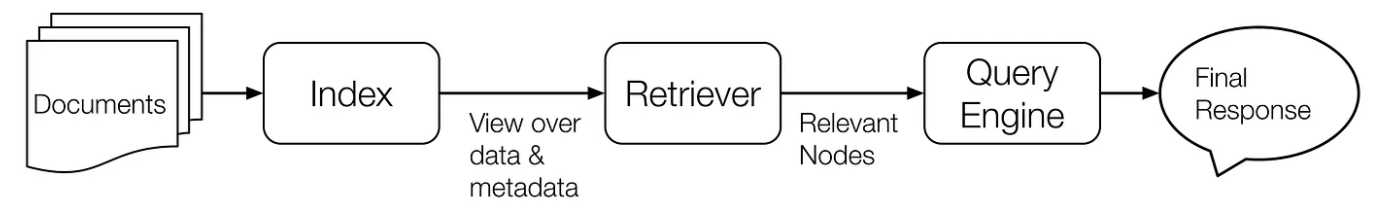

We can understand the core components of Llamaindex with this analogy:
1. Documents: These are the "books" in your library.
2. Index: It's the "library" of your data - Stores your data.
3. Retriever: It's the "librarian" that finds relevant data - Finds data.
4. Response Synthesizer: It's the "storyteller" that creates a response - Makes responses.
5. QueryEngine: It's the "director" that makes everything work together - Coordinates everything.

#### Documents and Nodes
Documents in LlamaIndex may be different from your traditional perception of documents. <br>
Document and Node objects are core abstractions within LlamaIndex.

A **Document** is a generic container around any data source - for instance, a PDF, an API output, or retrieved data from a database. They can be constructed manually, or created automatically via data loaders. By default, a Document stores text along with some other attributes. Some of these are

`metadata` - a dictionary of annotations that can be appended to the text (basically, additional info about the document) <br>
`relationships` - a dictionary containing relationships to other Documents/Nodes.

<br>

A **Node** represents a "chunk" of a source Document, whether that is a text chunk, an image, or other. Similar to Documents, they contain metadata and relationship information with other nodes.

Nodes are a first-class citizen in LlamaIndex. You can choose to define Nodes and all its attributes directly. You may also choose to "parse" source Documents into Nodes through our `NodeParser` classes. By default every Node derived from a Document will inherit the same metadata from that Document (e.g. a "file_name" filed in the Document is propagated to every Node).

Both Documents and Nodes have unique identifies called `ID`. These can be set automatically or manually. `ID` is generally used to identify, update, and define relationships between documents (or nodes).

For additional reading: [LlamaIndex Documentation](https://docs.llamaindex.ai/en/stable/module_guides/loading/documents_and_nodes/#documents-nodes)

### Vector Store

One of the most common ways to store and search over unstructured data is to embed it and store the resulting embedding vectors, and then at query time to embed the unstructured query and retrieve the embedding vectors that are 'most similar' to the embedded query. A vector store takes care of storing embedded data and performing vector search for you.

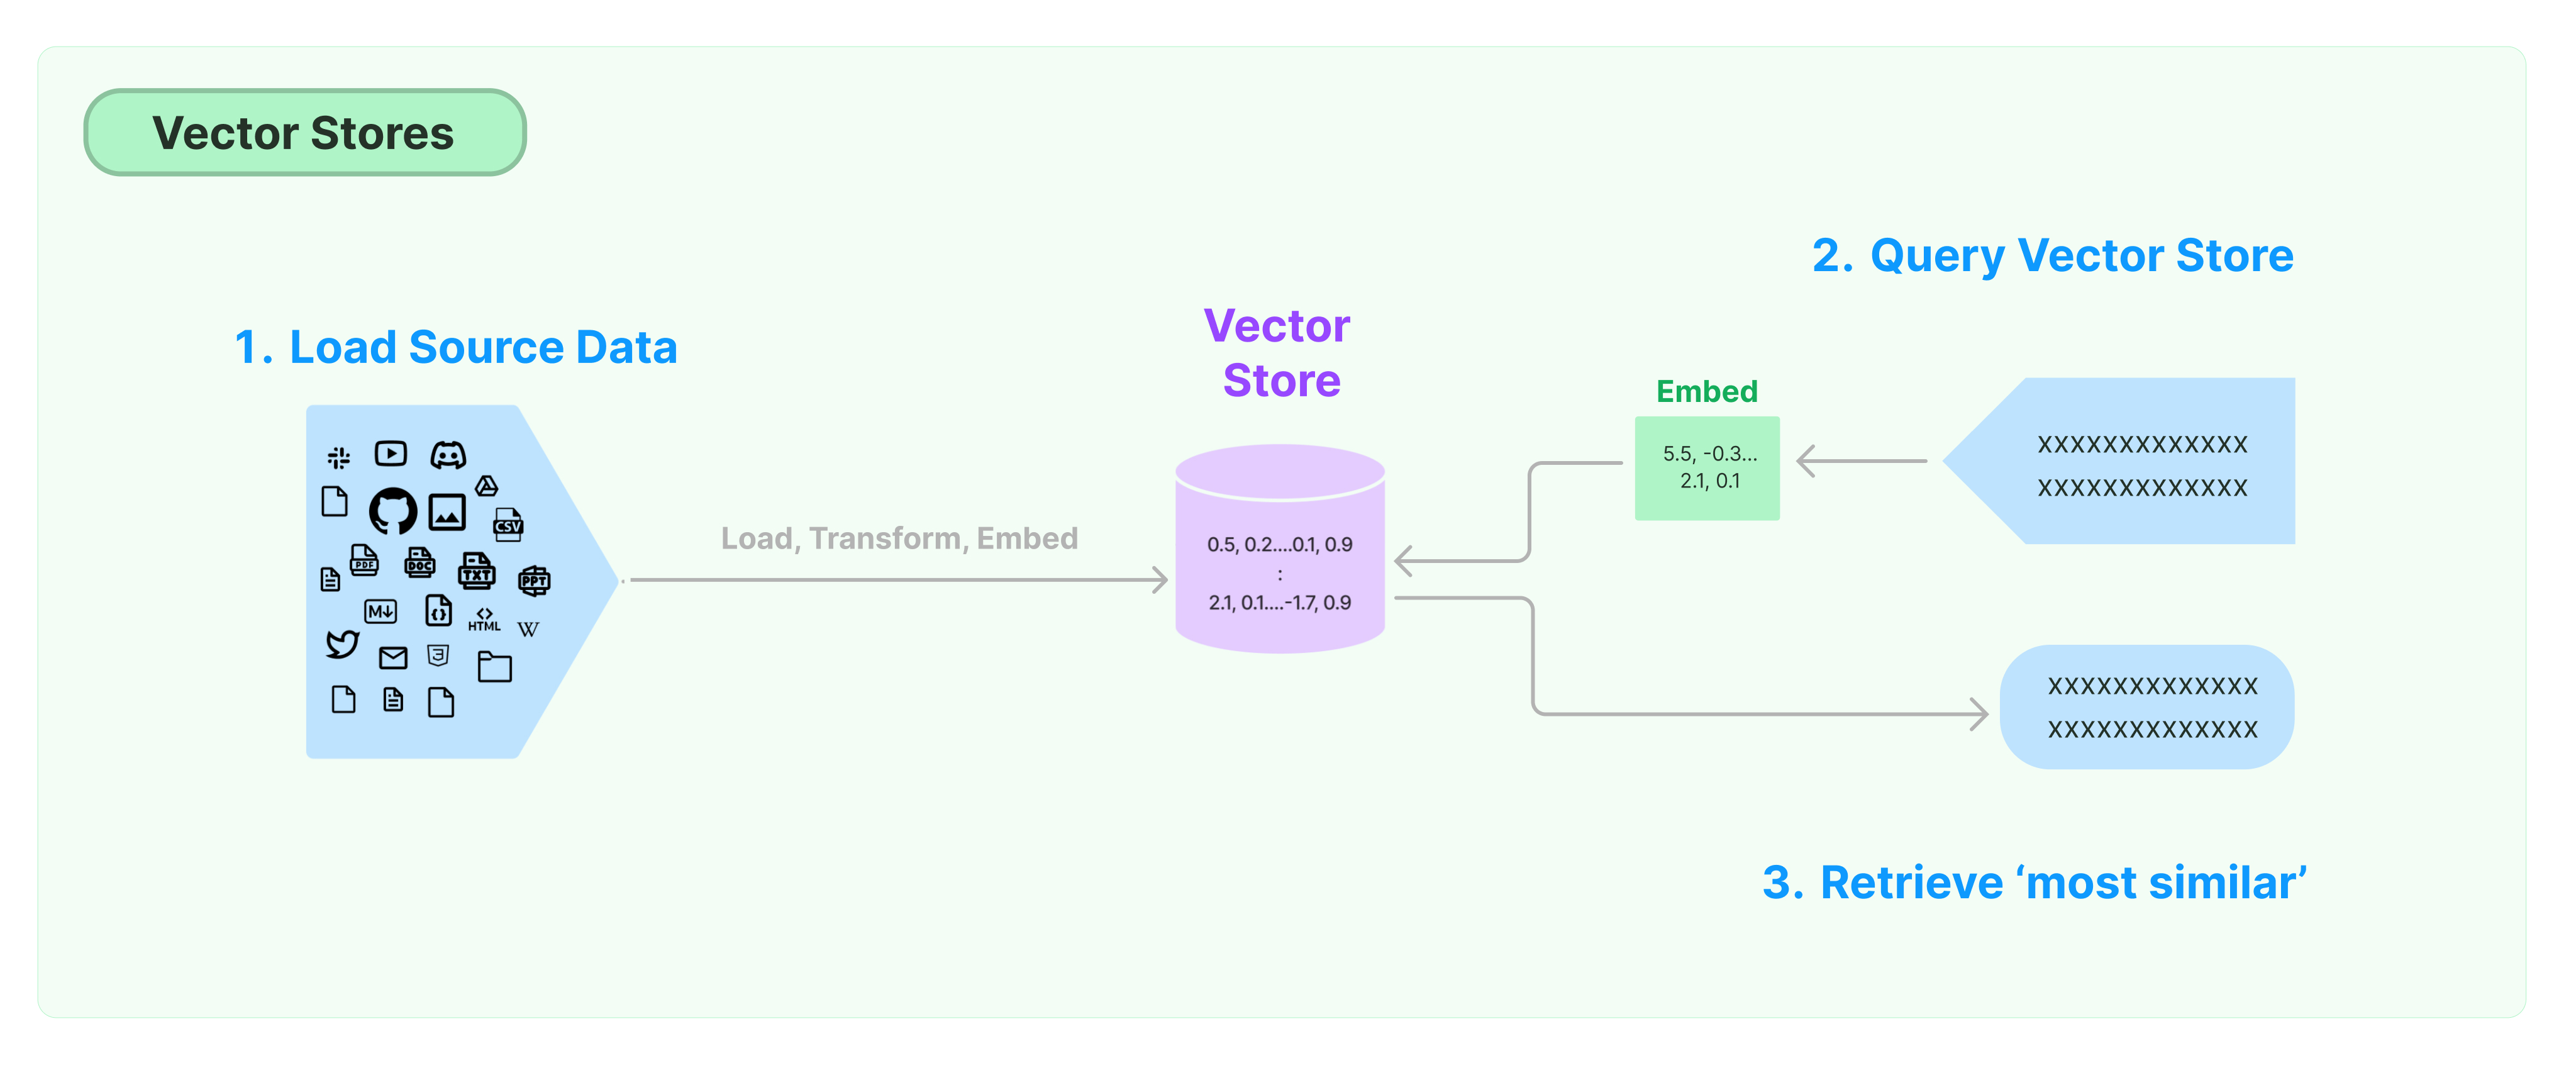

### Vector Store Index

##### Using VectorStoreIndex#
Vector Stores are a key component of RAG and so you will end up using them in nearly every application you make using LlamaIndex, either directly or indirectly.

Vector stores accept a list of Node objects and build an index from it.
<br>

**Loading data into the index**

The simplest way to use a Vector Store is to load a set of documents and build an index from them using from_documents:

###  Building the query engine
A Query Engine wraps a Retriever and a ResponseSynthesizer into a pipeline. It uses the query string to fetch nodes and then sends them to the Large Language Model (LLM) to generate a response.

In [15]:
from llama_index.core.node_parser import SimpleNodeParser
from llama_index.core import VectorStoreIndex
from IPython.display import display, HTML

In [16]:
# create parser and parse document into nodes
parser = SimpleNodeParser.from_defaults()
nodes = parser.get_nodes_from_documents(documents)

# # build index
index = VectorStoreIndex(nodes)

# Construct Query Engine
query_engine = index.as_query_engine()

####  Checking respones and respone parameters

In [17]:
response = query_engine.query("What is the policy's grace period and the consequences of missing a premium payment?")

In [18]:
#Checking the response
response.response

"The policy's grace period is fifteen (15) days for Monthly mode and thirty (30) days for Quarterly and Half-Yearly modes. If the premium is not paid within the grace period, the policy will lapse and have no further value."

In [19]:
#Check the source node
response.source_nodes

[NodeWithScore(node=TextNode(id_='8b008100-ff6c-4321-b295-c24f9977be6c', embedding=None, metadata={'page_label': '17', 'file_name': 'HDFC-Life-Group-Term-Life-Policy.pdf', 'file_path': 'D:\\GenAI\\semantic spotter projects\\data\\HDFC-Life-Group-Term-Life-Policy.pdf', 'file_type': 'application/pdf', 'file_size': 874679, 'creation_date': '2024-09-21', 'last_modified_date': '2024-08-15'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='66e07228-4b66-4fa5-94de-9540bafbcdea', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'page_label': '17', 'file_name': 'HDFC-Life-Group-Term-Life-Policy.pdf', 'file_path': 'D:\\GenAI\\semantic spotter projects\\data\\HDFC-Life-Group-Term-Life-Policy.pdf', 'file_type': 'applica

In [20]:
#Extract the file name
response.source_nodes[0].node.metadata['file_name']

'HDFC-Life-Group-Term-Life-Policy.pdf'

In [21]:
#Extract the score
response.source_nodes[1].score

0.850924681084094

# Reranking

In [22]:
from llama_index.core.postprocessor import SentenceTransformerRerank

In [23]:
rerank = SentenceTransformerRerank(
    model="cross-encoder/ms-marco-MiniLM-L-2-v2", top_n=3
)


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/62.5M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

#### Creating query Engine

In [69]:
# customizing the prompts.
from llama_index.core import PromptTemplate

text_qa_template_str = (
    "Context information is"
    " below.\n---------------------\n{context_str}\n---------------------\nUsing"
    " both the context information and also using your own knowledge, answer"
    " the question: {query_str}\nIf the context isn't helpful, you can also"
    " answer the question on your own.\n"
)
text_qa_template = PromptTemplate(text_qa_template_str)


refine_template_str = (
    "The original question is as follows: {query_str}\nWe have provided an"
    " existing answer: {existing_answer}\nWe have the opportunity to refine"
    " the existing answer (only if needed) with some more context"
    " below.\n------------\n{context_msg}\n------------\nUsing both the new"
    " context and your own knowledge, update or repeat the existing answer.\n"
)
refine_template = PromptTemplate(refine_template_str)

In [75]:
from llama_index.llms.openai import OpenAI
gpt_35llm = OpenAI(model="gpt-3.5-turbo", max_tokens=256)
gpt_4llm = OpenAI(model="gpt-4", max_tokens=256)# this will be used for evaluation

query_engine_RR = index.as_query_engine(
     similarity_top_k=5,
        node_postprocessors=[rerank],
        text_qa_template=text_qa_template,
        refine_template=refine_template,
        llm=gpt_35llm
)

In [76]:
response = query_engine_RR.query(
    "What are the eligibility criteria for becoming an insured member under the group life insurance policy?"
)


In [35]:
# Response node text
response.source_nodes[0].node.text

'F.3. Eligibility Criteria  \n \nF.3.1 Only a person who satisfies the below mentioned Eligibility Criteria and is aged less than the Benefit  Expiry \nAge (“an Eligible Member”) can be covered under this Policy  for the Benefit s described under this Policy  as per \nCoverage Schedule.  \n \nF.3.2 An Application for Cover shall be made in writing by the Policy  Holder on behalf of the Eligible Member \nwithin thirty (30) days from the date on which Eligible Member satisfies the Eligibility Criteria and application for \ncover  failing which the Policy  Holder shall furnish, at his own expense, evidence of his insurabi lity which is \nsatisfactory to the Company.  \n \nF.3.3.1 The application for cover must provide the true and correct  information in respect of an Eligible Member \nwhich is required by the Company.  PART F  \nGeneral Terms and Conditions'

#### Generating The Evaluators with LLM gpt-4

In [78]:
faithfulness_gpt4 = FaithfulnessEvaluator(llm=gpt_4llm)
relevancy_gpt4 = RelevancyEvaluator(llm=gpt_4llm)
correctness_gpt4 = CorrectnessEvaluator(llm=gpt_4llm)

#### Creating a cache Layer

In [42]:
!pip install diskcache
import openai
import diskcache as dc

cache = dc.Cache('./gpt_cache')


Defaulting to user installation because normal site-packages is not writeable


In [43]:
cache.set("A", "answer")

True

In [44]:
print(cache.get("A"))

answer


### Creating a response Pipeline



In [79]:
def query_response(user_input):
    final_response=""
    cache_response=None
    cache_response=cache.get(user_input)
    if cache_response is None:
        response=query_engine_RR.query(user_input)
        faithfulness_result = faithfulness_gpt4.evaluate_response(response=response)
        relevancy_result = relevancy_gpt4.evaluate_response(query=user_input, response=response)
        correctness_result = correctness_gpt4.evaluate_response(
        query=user_input,
        response=response,
        )
        print("Answer from LLM:\n")
        file_name = response.source_nodes[0].node.metadata['file_name'] + " Page No " + response.source_nodes[0].node.metadata['page_label'] + "\n"
   
        response = response.response + '\nCheck further at ' + file_name + ' for document references.'+'\nSimilarity score is :' + str(response.source_nodes[1].score)+ "\n" + f"Faithfulness Score: {faithfulness_result.score}\n" + f"Relevancy Score: {relevancy_result.score}\n" + f"Correctness Score: {correctness_result.score}\n"
        cache.set(user_input, response)
        final_response=response
    else:
        print("Answer  from cache:\n")
        final_response=cache_response

    return final_response


In [81]:
print(query_response("What is the process for resolving grievances related to HDFC Life insurance policies?"))


Answer from LLM:

The process for resolving grievances related to HDFC Life insurance policies involves the following steps:

1. The customer can contact the Grievance Redressal Officer at HDFC Life Insurance Company Limited via phone, email, or in person at the specified address.
2. All grievances (related to service and sales) will be responded to within 15 days.
3. A written request or email from the registered email id is mandatory.
4. Complaints may be investigated through telephone conversations or personal meetings.
5. An acknowledgement letter will be issued to the customer within 3 working days of receiving the complaint.
6. The acknowledgement will include details of the complaint number, policy number, and the Grievance Redressal Officer's name.
7. If the complaint is addressed within 3 days, the resolution communication will also serve as an acknowledgment.
8. The final resolution letter will offer redressal or rejection of the complaint with appropriate reasons.
9. If the 

In [82]:
def initialize_conv():
  print('Feel free to ask Questions regarding HDFC insurance.Press exit once you are done')
  while True:
    user_input = input()
    if user_input.lower() == 'exit':
      print('Exiting the program... bye')
      break
    else:
      response = query_response(user_input)
      display(HTML(f'<p style="font-size:20px">{response}</p>'))

In [84]:
initialize_conv()

Feel free to ask Questions regarding HDFC insurance.Press exit once you are done
How can one escalate a grievance if they are dissatisfied with HDFC Life’s response?
Answer from LLM:



. What is the loan facility in the HDFC Life Sanchay Plus plan, and what are the conditions?
Answer from LLM:



exit
Exiting the program... bye


### Build a Testing Pipeline

Here we feed a series of questions to the Q/A bot and store the responses along with the feedback on whether it's accurate or not from the user

In [85]:
def testing_pipeline(questions):
  test_feedback  = []
  for i in questions:
    print(i)
    print(query_response(i))
    print('\n Please provide your feedback on the response provided by the bot')
    user_input = input()
    test_feedback.append((i,query_response(i),user_input))
  feedback_df = pd.DataFrame(test_feedback, columns =['Question', 'Response', 'Good or Bad'])
  return feedback_df

In [86]:
import pandas as pd

In [89]:
# Definig the user query.
questions = ['Can a lapsed policy be revived, and what is the process?', 'Does the policy provide any surrender value, and under what conditions is it applicable?','What are the conditions for repaying a loan under HDFC Life policies?',
             'What is the loan facility in the HDFC Life Sanchay Plus plan, and what are the conditions?']

In [90]:
testing_pipeline(questions)

Can a lapsed policy be revived, and what is the process?
Answer from LLM:

Yes, a lapsed policy can be revived within a certain period of time. In the provided context from the HDFC Life Sampoorna Jeevan policy document, a lapsed policy may be revived for full benefits within five years from the due date for payment of the first unpaid premium. 

The process for reviving a lapsed policy typically involves the policyholder submitting a written application for revival to the insurance company, along with evidence of insurability and health of the life assured, to the satisfaction of the company. The company will then review the application and may require additional information or medical examinations. 

If the revival is approved, the policyholder will need to pay all amounts necessary to revive the policy, including any arrears premiums with interest or revival charges as specified by the company. Once the revival process is complete and approved by the company, the policy will be rein

,Question,Response,Good or Bad
0,"Can a lapsed policy be revived, and what is th...","Yes, a lapsed policy can be revived within a c...",good
1,"Does the policy provide any surrender value, a...",The policy provides a surrender value under sp...,good
2,What are the conditions for repaying a loan un...,The conditions for repaying a loan under HDFC ...,good
3,What is the loan facility in the HDFC Life San...,The loan facility in the HDFC Life Sanchay Plu...,good


 ### Building a custom prompt template


In [91]:
print(query_response("What are the benefits of group life insurance under HDFC Life Group Term Policy?"))


Answer from LLM:

The benefits of group life insurance under HDFC Life Group Term Policy include:
1. Payment of Sum Assured in case of death of the Insured Member during the term of the Insurance Cover.
2. Additional Sum Assured in case of Accidental Death of an Insured Member, if opted by the Policyholder.
3. Designation of nominees by the Insured Member to whom the benefits will be payable in the event of death.
4. Flexibility for the Insured Member to change the nominee during their lifetime.
5. Payment of claim proceeds to the Master Policyholder in case of Affinity Group with a lender-borrower relationship, with any remaining amount being paid to the nominee of the Insured Member.
6. No exclusion for suicide in Employer-Employee Group, ensuring full death benefit in such cases.
7. Exclusions for accidental death cover include specific scenarios such as disease or infection, intentional self-inflicted injury, participation in hazardous activities, etc.
8. All benefits and sums unde

In [92]:
response.source_nodes

[NodeWithScore(node=TextNode(id_='9b965425-a5ae-4d88-8047-359466a08951', embedding=None, metadata={'page_label': '14', 'file_name': 'HDFC-Life-Group-Term-Life-Policy.pdf', 'file_path': 'D:\\GenAI\\semantic spotter projects\\data\\HDFC-Life-Group-Term-Life-Policy.pdf', 'file_type': 'application/pdf', 'file_size': 874679, 'creation_date': '2024-09-21', 'last_modified_date': '2024-08-15'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='135d42aa-ebae-4496-9933-381b31899e93', node_type=<ObjectType.DOCUMENT: '4'>, metadata={'page_label': '14', 'file_name': 'HDFC-Life-Group-Term-Life-Policy.pdf', 'file_path': 'D:\\GenAI\\semantic spotter projects\\data\\HDFC-Life-Group-Term-Life-Policy.pdf', 'file_type': 'applica

In [96]:
response.source_nodes[0].node.text

'F.3. Eligibility Criteria  \n \nF.3.1 Only a person who satisfies the below mentioned Eligibility Criteria and is aged less than the Benefit  Expiry \nAge (“an Eligible Member”) can be covered under this Policy  for the Benefit s described under this Policy  as per \nCoverage Schedule.  \n \nF.3.2 An Application for Cover shall be made in writing by the Policy  Holder on behalf of the Eligible Member \nwithin thirty (30) days from the date on which Eligible Member satisfies the Eligibility Criteria and application for \ncover  failing which the Policy  Holder shall furnish, at his own expense, evidence of his insurabi lity which is \nsatisfactory to the Company.  \n \nF.3.3.1 The application for cover must provide the true and correct  information in respect of an Eligible Member \nwhich is required by the Company.  PART F  \nGeneral Terms and Conditions'

In [100]:
reference_N0 = " Check further at " + response.source_nodes[0].node.metadata['file_name'] + " Page No " + response.source_nodes[0].node.metadata['page_label']
reference_N1 = " Check further at " + response.source_nodes[1].node.metadata['file_name'] + " Page No " + response.source_nodes[1].node.metadata['page_label']
retrieved = response.source_nodes[0].node.text + reference_N0 + response.source_nodes[1].node.text + reference_N1
print(retrieved)

F.3. Eligibility Criteria  
 
F.3.1 Only a person who satisfies the below mentioned Eligibility Criteria and is aged less than the Benefit  Expiry 
Age (“an Eligible Member”) can be covered under this Policy  for the Benefit s described under this Policy  as per 
Coverage Schedule.  
 
F.3.2 An Application for Cover shall be made in writing by the Policy  Holder on behalf of the Eligible Member 
within thirty (30) days from the date on which Eligible Member satisfies the Eligibility Criteria and application for 
cover  failing which the Policy  Holder shall furnish, at his own expense, evidence of his insurabi lity which is 
satisfactory to the Company.  
 
F.3.3.1 The application for cover must provide the true and correct  information in respect of an Eligible Member 
which is required by the Company.  PART F  
General Terms and Conditions Check further at HDFC-Life-Group-Term-Life-Policy.pdf Page No 14F&U dated 15th October  2022                  UIN-101N169V0 2  P a g e  | 14      

In [101]:
messages = [
    {"role":"system", "content":"You are an AI assistant to user."},
    {"role":"user", "content":f"""What are the exclusions applicable to accidental death benefits in the policy? Check in '{retrieved}' """},
          ]

In [102]:
response2=openai.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=messages
)
response2.choices[0].message.content

'I do not see specific exclusions applicable to accidental death benefits mentioned in the sections you provided. The information mainly focuses on eligibility criteria, application processes, and terms related to insurance cover under the policy. If you are looking for specific exclusions related to accidental death benefits, you may need to refer to a section that directly addresses the terms and conditions of accidental death coverage within the policy document. It is essential to review the complete policy document for a comprehensive understanding of the coverage, exclusions, and conditions associated with accidental death benefits.'

#### Using Customized Nodes and LLMs***

In [105]:
from llama_index.embeddings.openai import OpenAIEmbedding
from llama_index.core.node_parser import SentenceSplitter
from llama_index.llms.openai import OpenAI
from llama_index.core import Settings

##Initialize the OpenAI model
Settings.llm = OpenAI(model="gpt-3.5-turbo", temperature=0, max_tokens=256)

##Initialize the embedding model
Settings.embed_model = OpenAIEmbedding()

## Initialize the node_parser with the custom node settings
Settings.node_parser = SentenceSplitter(chunk_size=512, chunk_overlap=100)

## Initialize the num_output and the context window
Settings.num_output = 512
Settings.context_window = 3900

# Create a VectorStoreIndex from a list of documents using the service context
index = VectorStoreIndex.from_documents(documents)

# Initialize a query engine for the index with a specified similarity top-k value
query_engine_custom = index.as_query_engine(similarity_top_k=3)

In [106]:
#Query the engine with a specific question
response_custom = query_engine_custom.query("How is the Free Cover Limit defined and applied to group term insurance?")

In [107]:
response_custom.response

'The Free Cover Limit (FCL) is defined as the amount of insurance or Sum Assured provided to a member without any medical underwriting. In the context of group term insurance, the Free Cover Limit is applied by offering coverage up to a certain amount without the need for the member to undergo a medical examination or provide detailed health information. This allows eligible members to receive a predetermined level of insurance coverage without the usual medical underwriting process.'

In [110]:
reference_C0 = " Check further at " + response_custom.source_nodes[0].node.metadata['file_name'] + " Page No " + response_custom.source_nodes[0].node.metadata['page_label']
reference_C1 = " Check further at " + response_custom.source_nodes[1].node.metadata['file_name'] + " Page No " + response_custom.source_nodes[1].node.metadata['page_label']
retrieved_c = response_custom.source_nodes[0].node.text + reference_C0 + response_custom.source_nodes[1].node.text + reference_C1
print(retrieved_c)

F&U dated 15th October  2022                  UIN-101N169V0 2  P a g e  | 13                        
  
 
F.1. Basic Policy  Contract  
 
F.1.1 This group term life insurance Policy  contract is entered into by the Company with Policy  Holder identified in 
the Schedule to this Policy  and the Policy  Holder shall hold this Policy  contract and all Benefit s payable hereunder 
upon trust for the Benefit  of the Insured Member s in accordance with this Policy  and as per the details in Coverage 
Schedule hereto. This Policy  witnesses a contract between the Policy  Holder and the Company . 
 
F.1.2 This Policy  is issued pursuant to a Proposal made to the Company by the Policy  Holder which is supported 
by an application for cover , completed and signed by the Policy  Holder on behalf of the persons for whose Benefit s 
the Policy  is affected.  
 
F.1.3  The cover for each Insured Member  under this Policy  shall come into effect on the Risk Commencement 
Date as identified in Policy 

In [116]:
messages_c = [
    {"role":"system", "content":"You are an AI assistant to user."},
    {"role":"user", "content":f"""Does the policy provide any surrender value, and under what conditions is it applicable? Check in '{retrieved_c}' """},
          ]

In [117]:
response_c = openai.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages_c)
response_c.choices[0].message.content

'I couldn\'t find specific information regarding surrender value in the provided text. It seems to focus more on the terms and conditions of the policy, eligibility criteria, fraud and misstatement provisions, and various definitions related to the policy itself. To obtain information about surrender value and the conditions under which it is applicable, it would be best to refer directly to the policy document titled "HDFC-Life-Group-Term-Life-Policy.pdf" provided on Page No. 14. You may find more detailed information regarding surrender value within that document.'

### Alternative Solution:
- Instead of usign diskcache we can use GPTCache.
- Other reranking option like cohere could be used.

### Conclusion :
This project built an efficient query engine that quickly finds relevant information from documents and combines it with the conversational power of GPT-3.5-turbo with Llamaindex framework. It not only retrieves useful information but also improves the responses and adapts based on user feedback. The system can be further developed and applied to other areas like law, education, or finance, making it versatile beyond just insurance.